## THIS IS A TEST NB USED FOR TESTING

`sfu_all_authors.csv` is old
`sfu_all_authors_2.csv` is using the `affiliations.institution.lineage` keyword in the API url, but it appears to be including authors that are irrelevant/not actually from SFU. 
`sfu_all_authors_3.csv` is using the `affiliations.institution.id` keyword in the API url. 

our objective is to see if `sfu_all_authors_3.csv` is complete without including extra stuff. 

In [2]:
# import libraries 

import pandas as pd
import numpy as np
from scipy import stats
import json
import ast
import fuzzywuzzy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from datetime import datetime
from tqdm import tqdm 
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import pandas as pd
import numpy as np
import json
import ast
import fuzzywuzzy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from datetime import datetime
from tqdm import tqdm 
from collections import defaultdict

In [3]:
# script to aggregate dicts for later 

def merge_year_dict_lists(list1, list2):
    combined = list1 + list2
    merged = defaultdict(lambda: {
        "year": None,
        "works_count": 0,
        "oa_works_count": 0,
        "cited_by_count": 0
    })
    
    for item in combined:
        year = item["year"]
        merged[year]["year"] = year
        merged[year]["works_count"] += item.get("works_count", 0)
        merged[year]["oa_works_count"] += item.get("oa_works_count", 0)
        merged[year]["cited_by_count"] += item.get("cited_by_count", 0)
    
    # return sorted list 
    return sorted(merged.values(), key=lambda x: x["year"])

## `sfu_all_authors_2.csv`

### 1. Read and clean OpenAlex author data for SFU 

For the sake of simplicity, limit only to authors who have at least 1 publication since 2020. 

In [4]:
# read OpenAlex data 
oa_authors_raw = pd.read_csv("sfu_all_authors_2.csv")

#oa_authors_raw.head()

In [5]:
# clean OpenAlex data 

oa_authors_clean = oa_authors_raw

# check last year published and number of publications
oa_authors_clean['counts_clean'] = oa_authors_clean['counts_by_year'].apply(lambda x: ast.literal_eval(x))
oa_authors_clean['latest_year'] = oa_authors_clean['counts_clean'].apply(lambda x: x[-1]['year']) # -1 index grabs last year
oa_authors_clean['pubs_in_latest_yr'] = oa_authors_clean['counts_clean'].apply(lambda x: x[-1]['works_count'])

# get rid of unnecessary cols
oa_authors_clean = oa_authors_clean.drop(columns=['topic_share', 'x_concepts', 'counts_by_year', 'updated_date', 'created_date'])

# save only authors who have published since 2020
oa_authors_old = oa_authors_clean[oa_authors_clean['latest_year'] < 2020].reset_index().drop(columns=['index']) # keep for future reference if necessary 
oa_authors_clean = oa_authors_clean[oa_authors_clean['latest_year'] >= 2020].reset_index().drop(columns=['index']) # update clean table

# clean id col 
oa_authors_clean['id'] = oa_authors_clean['id'].apply(lambda x: x.lstrip('https://openalex.org/'))
oa_authors_clean['orcid'] = oa_authors_clean['orcid'].apply(lambda x: str(x).lstrip('https://orcid.org/'))

# deal with names
oa_authors_clean['name_raw'] = oa_authors_clean['display_name'].apply(lambda x: str(x).replace('.', '').replace("'", "").strip(' ').lower())
oa_authors_clean['last_name'] = oa_authors_clean['name_raw'].apply(lambda x: str(x).split(' ')[-1].strip(' '))
oa_authors_clean['last_init'] = oa_authors_clean['last_name'].apply(lambda x: str(x)[0])
oa_authors_clean['first_names'] = oa_authors_clean['name_raw'].apply(lambda x: str(str(x).split(' ')[0:-1]))
oa_authors_clean['potential_matches'] = [[] for _ in range(len(oa_authors_clean))]

# testing 
print(oa_authors_clean['counts_clean'][1][-1]['year'])
print(oa_authors_clean['latest_year'].unique())
print(oa_authors_clean['pubs_in_latest_yr'].unique())

#oa_authors_clean

2026
[2026 2025 2022 2024 2023 2020 2021 2027 2029]
[  44    1   64    2    5    9   18   27    8   10 2057 2021   12    6
    3    7   30   77    4  148   87   74   97   98   41  101   85  108
   40   83  100  104   17  112   76   91   94   14   99   29   25   31
   28   72   24   20   54   43   79   53   15   35   33   23   19   37
   82   48   26   57   32   69   46   11   61   42   34   60   78   45
   59   52   50  102   16   62   55   49   93   13   22  188   39   21
   58   96  132   73   56  144   70   75   66   67   71   68   36   38
  242  105  169   47   63]


### first catch and merge all exact matches 
THRESHOLD = 100

In [6]:
# first catch and merge all exact matches 
THRESHOLD = 100

perfect_matches = []
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S") 
filepath = f"./intermediate_results/perfect_name_matches_{timestamp}.csv"

for initial, group in tqdm(oa_authors_clean.groupby('last_init')): 
    names = group['name_raw'].to_list()
    ids = group['id'].to_list()

    for i in range(len(names)):
        for j in range(i+1, len(names)):
            name1 = names[i]
            name2 = names[j]

            similarity_score = fuzz.ratio(name1, name2)

            if(similarity_score >= THRESHOLD):
                perfect_matches.append({
                    'name1': name1,
                    'name2': name2, 
                    'id1': ids[i], 
                    'id2': ids[j], 
                    'similarity_score': similarity_score
                })

perfect_matches = pd.DataFrame(perfect_matches)
perfect_matches.to_csv(filepath)

#display(perfect_matches)

100%|██████████| 48/48 [04:22<00:00,  5.47s/it]


In [7]:
len(perfect_matches)

7965

In [8]:
# Build adjacency list
graph = defaultdict(set)

for _, row in perfect_matches.iterrows():
    graph[row['id1']].add(row['id2'])
    graph[row['id2']].add(row['id1'])


visited = set()
groups = []

for node in graph:
    if node not in visited:
        stack = [node]
        component = []

        while stack:
            current = stack.pop()
            if current not in visited:
                visited.add(current)
                component.append(current)
                stack.extend(graph[current] - visited)

        groups.append(component)


In [9]:
oa_authors_clean.columns

Index(['id', 'orcid', 'display_name', 'raw_author_names', 'full_name',
       'works_count', 'cited_by_count', 'summary_stats', 'ids', 'affiliations',
       'last_known_institutions', 'topics', 'display_name_alternatives',
       'block_key', 'works_api_url', 'counts_clean', 'latest_year',
       'pubs_in_latest_yr', 'name_raw', 'last_name', 'last_init',
       'first_names', 'potential_matches'],
      dtype='object')

In [10]:
# initialize deduplicated data table
oa_authors_deduplicated = oa_authors_clean

test = oa_authors_clean

for i in tqdm(range(len(groups))):

    #print(len(groups[i]))

    ids_test = groups[i]
    #print(ids_test)

    # make baby dataframe of duplicate author
    test = oa_authors_deduplicated[
        oa_authors_deduplicated['id'].isin(ids_test)
    ].reset_index(drop=True)

    # init new row
    new_row = test.iloc[[0]].copy()

    # 1. set id
    new_row['id'] = test.loc[0]['id']

    # loop rest of duplicate ids
    for j in range(1, len(groups[i])):
        # add potential id match
        idx = new_row.index[0]
        new_row.at[idx, 'potential_matches'] = (
            new_row.at[idx, 'potential_matches'] + [test.loc[j, 'id']]
        )

        # 2. resolve oricd
        if pd.notna(test.loc[0]['orcid']):
            new_row['orcid'] = test.loc[0]['orcid']
        elif pd.notna(test.loc[j, 'orcid']):
            new_row['orcid'] = test.loc[j]['orcid']
        else: 
            new_row['orcid'] = np.nan

        # 3. leave display name as is

        # 4. merge alt names 
        new_row['display_name_alternatives'] = new_row['display_name_alternatives'] + test.loc[j]['display_name_alternatives']
        
        # 5. sum works count
        new_row['works_count'] = new_row['works_count'] + test.loc[j]['works_count']
        
        # 6. sum citations count 
        new_row['cited_by_count'] = new_row['cited_by_count'] + test.loc[j]['cited_by_count']
        
        # 7. deal with summary stats (for later, for now keep biggest only)
        
        # 8. deal with ids (also for later)
        
        # 9. affiliations
        new_row['affiliations'] = new_row['affiliations'] + test.loc[j]['affiliations']
        
        # 10. last known inst
        #new_row['last_known_institutions'] = new_row['last_known_institutions'] + test.loc[j]['last_known_institutions']
        
        # 11. topics
        new_row['topics'] = new_row['topics'] + test.loc[j]['topics']
        
        # 12. works api
        new_row['works_api_url'] = new_row['works_api_url'] + test.loc[j]['works_api_url']
        
        # 13. counts
        new_row.at[idx, 'counts_clean'] = merge_year_dict_lists(
            new_row.at[idx, 'counts_clean'],
            test.loc[j, 'counts_clean']
        )

        # 14. latest year 
        new_row['latest_year'] = max(new_row['latest_year'][0], test['latest_year'][j])

        # 15. works in latest year
        latest_count = new_row.at[idx, 'counts_clean'][-1]['oa_works_count']
        new_row.at[idx, 'pubs_in_latest_yr'] = latest_count

        # 16. name is same 

        # 17. last name is same 

        # 18. last init is same 

        # 19. first names are same 

        # 20. potential matches dealt with above 

    oa_authors_deduplicated = oa_authors_deduplicated[~oa_authors_deduplicated["id"].isin(ids_test)]
    oa_authors_deduplicated = pd.concat([oa_authors_deduplicated, new_row], ignore_index=True)

100%|██████████| 1001/1001 [00:25<00:00, 39.95it/s]


#### now merge imperfect matches

test different values of the threshold to see what looks best

In [11]:
# Set the fuzzy-match threshold here
THRESHOLD = 85

imperfect_matches = []
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filepath = f"./intermediate_results/oa_imperfect_name_matches_{timestamp}.csv"

for initial, group in tqdm(oa_authors_deduplicated.groupby('last_init')):
    names = group['name_raw'].to_list()
    ids = group['id'].to_list()

    for i in range(len(names)):
        for j in range(i+1, len(names)):
            name1 = names[i]
            name2 = names[j]

            similarity_score = fuzz.ratio(name1, name2)

            if THRESHOLD <= similarity_score < 100:
                imperfect_matches.append({
                    'name1': name1,
                    'name2': name2,
                    'id1': ids[i],
                    'id2': ids[j],
                    'similarity_score': similarity_score
                })

matches = pd.DataFrame(imperfect_matches)
matches.to_csv(filepath)
print(f"Found {len(matches)} imperfect matches at threshold >= {THRESHOLD}")


100%|██████████| 48/48 [03:37<00:00,  4.52s/it]

Found 1996 imperfect matches at threshold >= 85


### ~~threshold used is 85~~ matched all correct matches found using the 75% threshold
See excel sheet for more detail 

In [12]:
# Build adjacency list
graph = defaultdict(set)

for _, row in matches.iterrows():
    graph[row['id1']].add(row['id2'])
    graph[row['id2']].add(row['id1'])


visited = set()
groups = []

for node in graph:
    if node not in visited:
        stack = [node]
        component = []

        while stack:
            current = stack.pop()
            if current not in visited:
                visited.add(current)
                component.append(current)
                stack.extend(graph[current] - visited)

        groups.append(component)


In [13]:
# initialize deduplicated data table
oa_authors_deduplicated_2 = oa_authors_deduplicated

test = oa_authors_deduplicated

for i in tqdm(range(len(groups))):

    #print(len(groups[i]))

    ids_test = groups[i]
    #print(ids_test)

    # make baby dataframe of duplicate author
    test = oa_authors_deduplicated_2[
        oa_authors_deduplicated_2['id'].isin(ids_test)
    ].reset_index(drop=True)

    # init new row
    new_row = test.iloc[[0]].copy()

    # 1. set id
    new_row['id'] = test.loc[0]['id']

    # loop rest of duplicate ids
    for j in range(1, len(groups[i])):
        # add potential id match
        idx = new_row.index[0]
        new_row.at[idx, 'potential_matches'] = (
            new_row.at[idx, 'potential_matches'] + [test.loc[j, 'id']]
        )

        # 2. resolve oricd
        if pd.notna(test.loc[0]['orcid']):
            new_row['orcid'] = test.loc[0]['orcid']
        elif pd.notna(test.loc[j, 'orcid']):
            new_row['orcid'] = test.loc[j]['orcid']
        else: 
            new_row['orcid'] = np.nan

        # 3. leave display name as is

        # 4. merge alt names 
        new_row['display_name_alternatives'] = new_row['display_name_alternatives'] + test.loc[j]['display_name_alternatives']
        
        # 5. sum works count
        new_row['works_count'] = new_row['works_count'] + test.loc[j]['works_count']
        
        # 6. sum citations count 
        new_row['cited_by_count'] = new_row['cited_by_count'] + test.loc[j]['cited_by_count']
        
        # 7. deal with summary stats (for later, for now keep biggest only)
        
        # 8. deal with ids (also for later)
        
        # 9. affiliations
        new_row['affiliations'] = new_row['affiliations'] + test.loc[j]['affiliations']
        
        # 10. last known inst
        #new_row['last_known_institutions'] = new_row['last_known_institutions'] + test.loc[j]['last_known_institutions']
        
        # 11. topics
        new_row['topics'] = new_row['topics'] + test.loc[j]['topics']
        
        # 12. works api
        new_row['works_api_url'] = new_row['works_api_url'] + test.loc[j]['works_api_url']
        
        # 13. counts
        new_row.at[idx, 'counts_clean'] = merge_year_dict_lists(
            new_row.at[idx, 'counts_clean'],
            test.loc[j, 'counts_clean']
        )

        # 14. latest year 
        new_row['latest_year'] = max(new_row['latest_year'][0], test['latest_year'][j])

        # 15. works in latest year
        latest_count = new_row.at[idx, 'counts_clean'][-1]['oa_works_count']
        new_row.at[idx, 'pubs_in_latest_yr'] = latest_count

        # 16. keep top name

        # 17. keep top last name

        # 18. keep top last init 

        # 19. keep top first names 

        # 20. potential matches dealt with above 

    oa_authors_deduplicated_2 = oa_authors_deduplicated_2[~oa_authors_deduplicated_2["id"].isin(ids_test)]
    oa_authors_deduplicated_2 = pd.concat([oa_authors_deduplicated_2, new_row], ignore_index=True)

  0%|          | 0/947 [00:00<?, ?it/s]

100%|██████████| 947/947 [00:25<00:00, 37.19it/s]


In [14]:
print(len(oa_authors_deduplicated_2))

16351


In [15]:
#oa_authors_deduplicated_2

oa_authors_deduplicated_2.to_csv("oa_authors_20-24_deduplicated_V2.csv", index=False)

## `sfu_all_authors_3.csv`

### 1. Read and clean OpenAlex author data for SFU 

For the sake of simplicity, limit only to authors who have at least 1 publication since 2020. 

In [16]:
# read OpenAlex data 
oa_authors_raw = pd.read_csv("sfu_all_authors_3.csv")

#oa_authors_raw.head()

In [17]:
# clean OpenAlex data 

oa_authors_clean = oa_authors_raw

# check last year published and number of publications
oa_authors_clean['counts_clean'] = oa_authors_clean['counts_by_year'].apply(lambda x: ast.literal_eval(x))
oa_authors_clean['latest_year'] = oa_authors_clean['counts_clean'].apply(lambda x: x[-1]['year']) # -1 index grabs last year
oa_authors_clean['pubs_in_latest_yr'] = oa_authors_clean['counts_clean'].apply(lambda x: x[-1]['works_count'])

# get rid of unnecessary cols
oa_authors_clean = oa_authors_clean.drop(columns=['topic_share', 'x_concepts', 'counts_by_year', 'updated_date', 'created_date'])

# save only authors who have published since 2020
oa_authors_old = oa_authors_clean[oa_authors_clean['latest_year'] < 2020].reset_index().drop(columns=['index']) # keep for future reference if necessary 
oa_authors_clean = oa_authors_clean[oa_authors_clean['latest_year'] >= 2020].reset_index().drop(columns=['index']) # update clean table

# clean id col 
oa_authors_clean['id'] = oa_authors_clean['id'].apply(lambda x: x.lstrip('https://openalex.org/'))
oa_authors_clean['orcid'] = oa_authors_clean['orcid'].apply(lambda x: str(x).lstrip('https://orcid.org/'))

# deal with names
oa_authors_clean['name_raw'] = oa_authors_clean['display_name'].apply(lambda x: str(x).replace('.', '').replace("'", "").strip(' ').lower())
oa_authors_clean['last_name'] = oa_authors_clean['name_raw'].apply(lambda x: str(x).split(' ')[-1].strip(' '))
oa_authors_clean['last_init'] = oa_authors_clean['last_name'].apply(lambda x: str(x)[0])
oa_authors_clean['first_names'] = oa_authors_clean['name_raw'].apply(lambda x: str(str(x).split(' ')[0:-1]))
oa_authors_clean['potential_matches'] = [[] for _ in range(len(oa_authors_clean))]

# testing 
print(oa_authors_clean['counts_clean'][1][-1]['year'])
print(oa_authors_clean['latest_year'].unique())
print(oa_authors_clean['pubs_in_latest_yr'].unique())

#oa_authors_clean

2026
[2026 2025 2022 2024 2023 2020 2021 2027 2028]
[   1   66    2    5    9    6 2747    7   18   29   12   13    8    4
   78  148    3   10   73   41   84   17   75   14   25   32   28   52
   71   24   20   85   54   53   15   76   35   33   43   23   19   37
   26   57   11   79   27   46   44   48   16   88   94   61   42   34
   60   83   45   59   50   63   74   49  188   39   21   58  132   22
   40  226  144   70   30   62   65   68   36   38   98  242  100   31
  105  169   47   55   64   67]


### first catch and merge all exact matches 
THRESHOLD = 100

In [18]:
# first catch and merge all exact matches 
THRESHOLD = 100

perfect_matches = []
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S") 
filepath = f"./intermediate_results/perfect_name_matches_{timestamp}.csv"

for initial, group in tqdm(oa_authors_clean.groupby('last_init')): 
    names = group['name_raw'].to_list()
    ids = group['id'].to_list()

    for i in range(len(names)):
        for j in range(i+1, len(names)):
            name1 = names[i]
            name2 = names[j]

            similarity_score = fuzz.ratio(name1, name2)

            if(similarity_score >= THRESHOLD):
                perfect_matches.append({
                    'name1': name1,
                    'name2': name2, 
                    'id1': ids[i], 
                    'id2': ids[j], 
                    'similarity_score': similarity_score
                })

perfect_matches = pd.DataFrame(perfect_matches)
perfect_matches.to_csv(filepath)

#display(perfect_matches)

  0%|          | 0/48 [00:00<?, ?it/s]

100%|██████████| 48/48 [04:14<00:00,  5.30s/it]


In [19]:
len(perfect_matches)

7790

In [20]:
# Build adjacency list
graph = defaultdict(set)

for _, row in perfect_matches.iterrows():
    graph[row['id1']].add(row['id2'])
    graph[row['id2']].add(row['id1'])


visited = set()
groups = []

for node in graph:
    if node not in visited:
        stack = [node]
        component = []

        while stack:
            current = stack.pop()
            if current not in visited:
                visited.add(current)
                component.append(current)
                stack.extend(graph[current] - visited)

        groups.append(component)


In [21]:
oa_authors_clean.columns

Index(['id', 'orcid', 'display_name', 'raw_author_names', 'full_name',
       'works_count', 'cited_by_count', 'summary_stats', 'ids', 'affiliations',
       'last_known_institutions', 'topics', 'display_name_alternatives',
       'block_key', 'works_api_url', 'counts_clean', 'latest_year',
       'pubs_in_latest_yr', 'name_raw', 'last_name', 'last_init',
       'first_names', 'potential_matches'],
      dtype='object')

In [22]:
# initialize deduplicated data table
oa_authors_deduplicated = oa_authors_clean

test = oa_authors_clean

for i in tqdm(range(len(groups))):

    #print(len(groups[i]))

    ids_test = groups[i]
    #print(ids_test)

    # make baby dataframe of duplicate author
    test = oa_authors_deduplicated[
        oa_authors_deduplicated['id'].isin(ids_test)
    ].reset_index(drop=True)

    # init new row
    new_row = test.iloc[[0]].copy()

    # 1. set id
    new_row['id'] = test.loc[0]['id']

    # loop rest of duplicate ids
    for j in range(1, len(groups[i])):
        # add potential id match
        idx = new_row.index[0]
        new_row.at[idx, 'potential_matches'] = (
            new_row.at[idx, 'potential_matches'] + [test.loc[j, 'id']]
        )

        # 2. resolve oricd
        if pd.notna(test.loc[0]['orcid']):
            new_row['orcid'] = test.loc[0]['orcid']
        elif pd.notna(test.loc[j, 'orcid']):
            new_row['orcid'] = test.loc[j]['orcid']
        else: 
            new_row['orcid'] = np.nan

        # 3. leave display name as is

        # 4. merge alt names 
        new_row['display_name_alternatives'] = new_row['display_name_alternatives'] + test.loc[j]['display_name_alternatives']
        
        # 5. sum works count
        new_row['works_count'] = new_row['works_count'] + test.loc[j]['works_count']
        
        # 6. sum citations count 
        new_row['cited_by_count'] = new_row['cited_by_count'] + test.loc[j]['cited_by_count']
        
        # 7. deal with summary stats (for later, for now keep biggest only)
        
        # 8. deal with ids (also for later)
        
        # 9. affiliations
        new_row['affiliations'] = new_row['affiliations'] + test.loc[j]['affiliations']
        
        # 10. last known inst
        #new_row['last_known_institutions'] = new_row['last_known_institutions'] + test.loc[j]['last_known_institutions']
        
        # 11. topics
        new_row['topics'] = new_row['topics'] + test.loc[j]['topics']
        
        # 12. works api
        new_row['works_api_url'] = new_row['works_api_url'] + test.loc[j]['works_api_url']
        
        # 13. counts
        new_row.at[idx, 'counts_clean'] = merge_year_dict_lists(
            new_row.at[idx, 'counts_clean'],
            test.loc[j, 'counts_clean']
        )

        # 14. latest year 
        new_row['latest_year'] = max(new_row['latest_year'][0], test['latest_year'][j])

        # 15. works in latest year
        latest_count = new_row.at[idx, 'counts_clean'][-1]['oa_works_count']
        new_row.at[idx, 'pubs_in_latest_yr'] = latest_count

        # 16. name is same 

        # 17. last name is same 

        # 18. last init is same 

        # 19. first names are same 

        # 20. potential matches dealt with above 

    oa_authors_deduplicated = oa_authors_deduplicated[~oa_authors_deduplicated["id"].isin(ids_test)]
    oa_authors_deduplicated = pd.concat([oa_authors_deduplicated, new_row], ignore_index=True)

100%|██████████| 902/902 [00:29<00:00, 31.02it/s]


#### now merge imperfect matches

test different values of the threshold to see what looks best

In [23]:
# Set the fuzzy-match threshold here
THRESHOLD = 85

imperfect_matches = []
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filepath = f"./intermediate_results/oa_imperfect_name_matches_{timestamp}.csv"

for initial, group in tqdm(oa_authors_deduplicated.groupby('last_init')):
    names = group['name_raw'].to_list()
    ids = group['id'].to_list()

    for i in range(len(names)):
        for j in range(i+1, len(names)):
            name1 = names[i]
            name2 = names[j]

            similarity_score = fuzz.ratio(name1, name2)

            if THRESHOLD <= similarity_score < 100:
                imperfect_matches.append({
                    'name1': name1,
                    'name2': name2,
                    'id1': ids[i],
                    'id2': ids[j],
                    'similarity_score': similarity_score
                })

matches = pd.DataFrame(imperfect_matches)
matches.to_csv(filepath)
print(f"Found {len(matches)} imperfect matches at threshold >= {THRESHOLD}")


100%|██████████| 48/48 [04:44<00:00,  5.93s/it]

Found 1954 imperfect matches at threshold >= 85


### ~~threshold used is 85~~ matched all correct matches found using the 75% threshold
See excel sheet for more detail 

In [24]:
# Build adjacency list
graph = defaultdict(set)

for _, row in matches.iterrows():
    graph[row['id1']].add(row['id2'])
    graph[row['id2']].add(row['id1'])


visited = set()
groups = []

for node in graph:
    if node not in visited:
        stack = [node]
        component = []

        while stack:
            current = stack.pop()
            if current not in visited:
                visited.add(current)
                component.append(current)
                stack.extend(graph[current] - visited)

        groups.append(component)


In [25]:
# initialize deduplicated data table
oa_authors_deduplicated_2 = oa_authors_deduplicated

test = oa_authors_deduplicated

for i in tqdm(range(len(groups))):

    #print(len(groups[i]))

    ids_test = groups[i]
    #print(ids_test)

    # make baby dataframe of duplicate author
    test = oa_authors_deduplicated_2[
        oa_authors_deduplicated_2['id'].isin(ids_test)
    ].reset_index(drop=True)

    # init new row
    new_row = test.iloc[[0]].copy()

    # 1. set id
    new_row['id'] = test.loc[0]['id']

    # loop rest of duplicate ids
    for j in range(1, len(groups[i])):
        # add potential id match
        idx = new_row.index[0]
        new_row.at[idx, 'potential_matches'] = (
            new_row.at[idx, 'potential_matches'] + [test.loc[j, 'id']]
        )

        # 2. resolve oricd
        if pd.notna(test.loc[0]['orcid']):
            new_row['orcid'] = test.loc[0]['orcid']
        elif pd.notna(test.loc[j, 'orcid']):
            new_row['orcid'] = test.loc[j]['orcid']
        else: 
            new_row['orcid'] = np.nan

        # 3. leave display name as is

        # 4. merge alt names 
        new_row['display_name_alternatives'] = new_row['display_name_alternatives'] + test.loc[j]['display_name_alternatives']
        
        # 5. sum works count
        new_row['works_count'] = new_row['works_count'] + test.loc[j]['works_count']
        
        # 6. sum citations count 
        new_row['cited_by_count'] = new_row['cited_by_count'] + test.loc[j]['cited_by_count']
        
        # 7. deal with summary stats (for later, for now keep biggest only)
        
        # 8. deal with ids (also for later)
        
        # 9. affiliations
        new_row['affiliations'] = new_row['affiliations'] + test.loc[j]['affiliations']
        
        # 10. last known inst
        #new_row['last_known_institutions'] = new_row['last_known_institutions'] + test.loc[j]['last_known_institutions']
        
        # 11. topics
        new_row['topics'] = new_row['topics'] + test.loc[j]['topics']
        
        # 12. works api
        new_row['works_api_url'] = new_row['works_api_url'] + test.loc[j]['works_api_url']
        
        # 13. counts
        new_row.at[idx, 'counts_clean'] = merge_year_dict_lists(
            new_row.at[idx, 'counts_clean'],
            test.loc[j, 'counts_clean']
        )

        # 14. latest year 
        new_row['latest_year'] = max(new_row['latest_year'][0], test['latest_year'][j])

        # 15. works in latest year
        latest_count = new_row.at[idx, 'counts_clean'][-1]['oa_works_count']
        new_row.at[idx, 'pubs_in_latest_yr'] = latest_count

        # 16. keep top name

        # 17. keep top last name

        # 18. keep top last init 

        # 19. keep top first names 

        # 20. potential matches dealt with above 

    oa_authors_deduplicated_2 = oa_authors_deduplicated_2[~oa_authors_deduplicated_2["id"].isin(ids_test)]
    oa_authors_deduplicated_2 = pd.concat([oa_authors_deduplicated_2, new_row], ignore_index=True)

100%|██████████| 925/925 [00:48<00:00, 19.10it/s]


In [26]:
print(len(oa_authors_deduplicated_2))

16039


In [27]:
#oa_authors_deduplicated_2

oa_authors_deduplicated_2.to_csv("oa_authors_20-24_deduplicated_V3.csv", index=False)

In [28]:
oa_auths_2 = pd.read_csv("oa_authors_20-24_deduplicated_V2.csv")
oa_auths_3 = pd.read_csv("oa_authors_20-24_deduplicated_V3.csv")

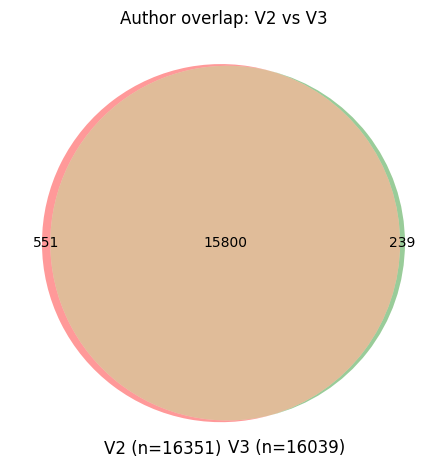

In [29]:
ids_v2 = set(oa_auths_2['id'].astype(str))
ids_v3 = set(oa_auths_3['id'].astype(str))

matched = ids_v2 & ids_v3
only_v2 = len(ids_v2 - ids_v3)
only_v3 = len(ids_v3 - ids_v2)
both = len(matched)

venn2(subsets=(only_v2, only_v3, both),
      set_labels=(f'V2 (n={len(ids_v2)})', f'V3 (n={len(ids_v3)})'))

plt.title('Author overlap: V2 vs V3')
plt.tight_layout()
plt.show()

In [31]:
oa_auths_2

,id,orcid,display_name,raw_author_names,full_name,works_count,cited_by_count,summary_stats,ids,affiliations,...,block_key,works_api_url,counts_clean,latest_year,pubs_in_latest_yr,name_raw,last_name,last_init,first_names,potential_matches
0,A5044512393,0000-0002-9850-1174,Mary L. Berbee,"['Berbee, M L', 'Berbee, Mary', 'Berbee, Mary ...","Berbee, Mary L.",370739,9517,"{'2yr_mean_citedness': 5.9360792196754045e-05,...",{'openalex': 'https://openalex.org/A5044512393...,[{'institution': {'id': 'https://openalex.org/...,...,m berbee,https://api.openalex.org/works?filter=author.i...,"[{'year': 1988, 'works_count': 3, 'oa_works_co...",2026,44,mary l berbee,berbee,b,"['mary', 'l']",[]
1,A5089379373,0000-0002-0293-964X,Ben Zhong Tang,"['B Tang', 'B. Tang', 'B. Z. Tang', 'B.Z Tang'...",Ben Zhong Tang,4140,249095,"{'2yr_mean_citedness': 14.726989079563182, 'h_...",{'openalex': 'https://openalex.org/A5089379373...,[{'institution': {'id': 'https://openalex.org/...,...,b tang,https://api.openalex.org/works?filter=author.i...,"[{'year': 1983, 'works_count': 2, 'oa_works_co...",2026,9,ben zhong tang,tang,t,"['ben', 'zhong']",[]
2,A5108047889,0000-0001-5697-0717,Yì Wáng,"['J Yi-Xiang Wang', 'J. Wang', 'J.W. Wang', 'J...",J Yi-Xiang Wang,3120,26307,"{'2yr_mean_citedness': 0.6116195781933943, 'h_...",{'openalex': 'https://openalex.org/A5108047889...,[{'institution': {'id': 'https://openalex.org/...,...,j wang,https://api.openalex.org/works?filter=author.i...,"[{'year': 1988, 'works_count': 1, 'oa_works_co...",2026,2057,yì wáng,wáng,w,['yì'],[]
3,A5019356592,0000-0001-9029-2462,J. B. Singh,"['Dr. Jaswinder Singh', 'H. Singh', 'J B SINGH...",Dr. Jaswinder Singh,2833,139593,"{'2yr_mean_citedness': 4.859106529209622, 'h_i...",{'openalex': 'https://openalex.org/A5019356592...,[{'institution': {'id': 'https://openalex.org/...,...,j singh,https://api.openalex.org/works?filter=author.i...,"[{'year': 1955, 'works_count': 1, 'oa_works_co...",2026,12,j b singh,singh,s,"['j', 'b']",[]
4,A5087003938,0000-0002-8482-5784,D. Gareth Evans,"['Anisimov', 'D D Evans', 'D EVANS', 'D Evans'...",D. Gareth Evans,2455,134866,"{'2yr_mean_citedness': 2.8711340206185567, 'h_...",{'openalex': 'https://openalex.org/A5087003938...,[{'institution': {'id': 'https://openalex.org/...,...,d evans,https://api.openalex.org/works?filter=author.i...,"[{'year': 1856, 'works_count': 1, 'oa_works_co...",2026,6,d gareth evans,evans,e,"['d', 'gareth']",[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16346,A5025292022,0000-0001-7827-5889,Vanja Zdjelar,['Vanja Zdjelar'],Vanja Zdjelar,6,26,"{'2yr_mean_citedness': 0.0, 'h_index': 2, 'i10...",{'openalex': 'https://openalex.org/A5025292022...,[{'institution': {'id': 'https://openalex.org/...,...,v zdjelar,https://api.openalex.org/works?filter=author.i...,"[{'year': 2019, 'works_count': 1, 'oa_works_co...",2025,0,vanja zdjelar,zdjelar,z,['vanja'],['A5114472761']
16347,A5027966459,0009-0001-4780-9240,H.H. Zhang,"['H.H. Zhang', 'Huai Zhang']",Huai Zhang,6,128,"{'2yr_mean_citedness': 0.0, 'h_index': 2, 'i10...",{'openalex': 'https://openalex.org/A5027966459...,[{'institution': {'id': 'https://openalex.org/...,...,h zhang,https://api.openalex.org/works?filter=author.i...,"[{'year': 1994, 'works_count': 1, 'oa_works_co...",2024,0,hh zhang,zhang,z,['hh'],['A5037533851']
16348,A5076476694,0000-0003-1555-7920,Yuan Zhao,"['Y Zhao', 'Y. S. Zhao', 'Y. Zhao', 'Yuan ZHAO...",Yuan Zhao,508,6252,"{'2yr_mean_citedness': 4.914893617021277, 'h_i...",{'openalex': 'https://openalex.org/A5076476694...,[{'institution': {'id': 'https://openalex.org/...,...,y zhao,https://api.openalex.org/works?filter=author.i...,"[{'year': 1988, 'works_count': 1, 'oa_works_co...",2026,63,yuan zhao,zhao,z,['yuan'],"['A5075689961', 'A5114832292']"
16349,A5055904501,0000-0001-8058-3522,Zhe George Zhang,"['Zhang, Zhe George', 'Zhe George Zhang', 'Zh...","Zhang, Zhe George",243,7775,"{'2yr_mean_citedness': 0.4375, 'h_index': 37, ...",{'openalex': '

In [36]:
oa_auths_3['pubs_in_latest_yr'].describe()

count    16039.000000
mean         2.965771
std         22.467105
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       2747.000000
Name: pubs_in_latest_yr, dtype: float64

In [38]:
oa_auths_3[oa_auths_3['pubs_in_latest_yr'] == 2747]

,id,orcid,display_name,raw_author_names,full_name,works_count,cited_by_count,summary_stats,ids,affiliations,...,block_key,works_api_url,counts_clean,latest_year,pubs_in_latest_yr,name_raw,last_name,last_init,first_names,potential_matches
1,A5108047889,0000-0001-5697-0717,Yì Wáng,"['Chi Zhang', 'Hui Zong', 'J Yi-Xiang Wang', '...",J Yi-Xiang Wang,3864,26419,"{'2yr_mean_citedness': 0.49431992631255756, 'h...",{'openalex': 'https://openalex.org/A5108047889...,[{'institution': {'id': 'https://openalex.org/...,...,j wang,https://api.openalex.org/works?filter=author.i...,"[{'year': 1988, 'works_count': 1, 'oa_works_co...",2026,2747,yì wáng,wáng,w,['yì'],[]
